<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_Sparsity_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ── CELL 5: Results — improved figures ────────────────────────────
import json as _json, os as _os, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_FILE = f"{OUT_DIR}/sparsity_results_alpha{ALPHA}.json"

if "sparsity_results" not in dir() or len(sparsity_results) == 0:
    if _os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE) as f:
            sparsity_results = _json.load(f)
        for k in sparsity_results:
            sparsity_results[k]["Cp_pred"] = np.array(sparsity_results[k]["Cp_pred"])
            sparsity_results[k]["th_deg"]  = np.array(sparsity_results[k]["th_deg"])
        print(f"Loaded {len(sparsity_results)} results from Drive")

# ── Sensor positions for each NCp ────────────────────────────────
def get_sensor_angles(n_cp):
    if n_cp == 0 or n_cp is None:
        return np.array([])
    else:
        return np.linspace(0, 360, int(n_cp), endpoint=False)

sensor_angles = {
    "0":    get_sensor_angles(0),
    "4":    get_sensor_angles(4),
    "8":    get_sensor_angles(8),
    "16":   get_sensor_angles(16),
    "full": theta_exp,
}

# ── TABLE ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  SPARSITY STUDY — alpha={ALPHA}, Re={RE:.1e}")
print(f"{'='*70}")
print(f"  {'NCp':<10} {'MAE':>7} {'CL':>7} {'CL err%':>9} {'CD':>7} {'CD err%':>9} {'Cp_min':>8}")
print(f"  {'-'*68}")
for ncp_str, r in sparsity_results.items():
    cl_err = abs(r["CL"]-cl_ref)/cl_ref*100
    cd_err = abs(r["CD"]-cd_ref)/cd_ref*100
    cp_min = float(np.array(r["Cp_pred"]).min())
    print(f"  {r['label']:<14} {r['mae']:>6.3f}  {r['CL']:>6.3f}  {cl_err:>7.1f}%  "
          f"{r['CD']:>6.3f}  {cd_err:>7.1f}%  {cp_min:>7.2f}")
print(f"  {'-'*68}")
print(f"  Experiment:           CL={cl_ref:.3f}            CD={cd_ref:.3f}  Cp_min={cp_exp.min():.2f}")
print(f"{'='*70}")

colors = ["purple","blue","green","orange","red"]
labels_nice = {"0":"NCp=0\n(physics only)",
               "4":"NCp=4","8":"NCp=8",
               "16":"NCp=16","full":"NCp=full\n(30 pts)"}

# ── FIGURE 1: Cp grid with sensor positions marked ────────────────
n_runs = len(sparsity_results)
fig, axes = plt.subplots(1, n_runs, figsize=(4.5*n_runs, 4.5))
for ax, (ncp_str, r), col in zip(axes, sparsity_results.items(), colors):
    Cp_p = np.array(r["Cp_pred"]); th_p = np.array(r["th_deg"])
    ax.plot(th_p, Cp_p, "-", color=col, lw=2, label="PINN", zorder=2)
    ax.scatter(theta_exp, cp_exp, color="red", s=15, zorder=3,
               label="Exp.", marker="o")

    # Mark sensor positions
    s_angles = sensor_angles[ncp_str]
    if len(s_angles) > 0:
        s_cp = np.interp(s_angles, theta_exp, cp_exp)
        ax.scatter(s_angles, s_cp, color="black", s=80, zorder=5,
                  marker="^", label="Sensors", linewidths=1.5)

    ax.axhline(0, color="k", lw=0.5, ls="--")
    mae = r["mae"]
    ax.set_title(f"{labels_nice[ncp_str]}\nMAE={mae:.3f}", fontsize=9)
    ax.set_xlabel("θ (°)"); ax.set_ylabel("Cp")
    ax.set_xlim([0,360]); ax.set_xticks([0,90,180,270,360])
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f"Sparsity Study — Cp(θ) with sensor positions | α={ALPHA}, Re={RE:.1e}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_Cp_grid_v2.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 1 saved ✓")

# ── FIGURE 2: MAE/CL/CD vs NCp ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ncp_x      = list(range(n_runs))
ncp_labels = [labels_nice[k].replace("\n"," ") for k in sparsity_results]
maes  = [r["mae"] for r in sparsity_results.values()]
cls   = [r["CL"]  for r in sparsity_results.values()]
cds   = [r["CD"]  for r in sparsity_results.values()]
cpmins= [float(np.array(r["Cp_pred"]).min()) for r in sparsity_results.values()]

# MAE plot with elbow annotation
ax = axes[0]
bars = ax.bar(ncp_x, maes, color=colors, width=0.6, alpha=0.85)
ax.axhline(1.0, color="red", lw=1, ls="--", label="Target MAE=1.0")
# Mark elbow at NCp=8
elbow_idx = list(sparsity_results.keys()).index("8") if "8" in sparsity_results else 2
ax.axvline(elbow_idx, color="darkgreen", lw=1.5, ls=":", label=f"Elbow (NCp=8)")
ax.set_xticks(ncp_x); ax.set_xticklabels(ncp_labels, rotation=15, ha="right", fontsize=8)
ax.set_xlabel("Number of Cp sensors"); ax.set_ylabel("Cp MAE")
ax.set_title("Cp MAE vs sensor count\n▲ = optimal (elbow)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")
for i,v in enumerate(maes):
    ax.text(i, v+0.05, f"{v:.3f}", ha="center", fontsize=8)

# CL
axes[1].bar(ncp_x, cls, color=colors, width=0.6, alpha=0.85)
axes[1].axhline(cl_ref, color="navy", lw=2, ls="--", label=f"Exp={cl_ref:.3f}")
axes[1].set_xticks(ncp_x); axes[1].set_xticklabels(ncp_labels, rotation=15, ha="right", fontsize=8)
axes[1].set_xlabel("Number of Cp sensors"); axes[1].set_ylabel("C_L")
axes[1].set_title("Lift coefficient vs sensor count")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis="y")
for i,v in enumerate(cls):
    axes[1].text(i, max(v,0)+0.05, f"{v:.3f}", ha="center", fontsize=8)

# CD
axes[2].bar(ncp_x, cds, color=colors, width=0.6, alpha=0.85)
axes[2].axhline(cd_ref, color="darkred", lw=2, ls="--", label=f"Exp={cd_ref:.3f}")
axes[2].set_xticks(ncp_x); axes[2].set_xticklabels(ncp_labels, rotation=15, ha="right", fontsize=8)
axes[2].set_xlabel("Number of Cp sensors"); axes[2].set_ylabel("C_D")
axes[2].set_title("Drag coefficient vs sensor count")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="y")
for i,v in enumerate(cds):
    axes[2].text(i, max(v,0)+0.02, f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle(f"Sparsity Study — α={ALPHA}, Re={RE:.1e}", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_metrics_v2.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 2 saved ✓")

# ── FIGURE 3: Collocation points around cylinder ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: log-polar interior sampling distribution
np.random.seed(42)
n_show = 500
th_s  = np.random.uniform(0, 2*np.pi, n_show)
r_s   = np.exp(np.random.uniform(np.log(R_IN), np.log(min(R_OUT, 6.0)), n_show))
x_s   = r_s*np.cos(th_s); y_s = r_s*np.sin(th_s)
# Wall points
th_w  = np.linspace(0, 2*np.pi, N_WALL, endpoint=False)
xw_s  = (-R_IN*np.cos(th_w)); yw_s = (+R_IN*np.sin(th_w))

ax = axes[0]
cyl = plt.Circle((0,0), R_IN, color="grey", zorder=5, label="Cylinder")
ax.add_patch(cyl)
ax.scatter(x_s, y_s, s=3, color="steelblue", alpha=0.4, label=f"Interior ({n_show} shown)")
ax.scatter(xw_s, yw_s, s=8, color="red", zorder=4, label=f"Wall ({N_WALL} pts)")
ax.set_xlim([-6,6]); ax.set_ylim([-6,6])
ax.set_aspect("equal")
ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
ax.set_title(f"Collocation points (log-polar interior)\nN_INT={N_INT}  N_WALL={N_WALL}  N_FF={N_FF}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xticks([-6,-4,-2,0,2,4,6])

# Right: zoom near wall showing density
ax2 = axes[1]
mask_near = r_s < 3.0
cyl2 = plt.Circle((0,0), R_IN, color="grey", zorder=5)
ax2.add_patch(cyl2)
ax2.scatter(x_s[mask_near], y_s[mask_near], s=8, color="steelblue",
            alpha=0.5, label=f"Interior (r<3D)")
ax2.scatter(xw_s, yw_s, s=15, color="red", zorder=4, label=f"Wall ({N_WALL} pts)")

# Sensor positions for NCp=8 (optimal)
s8 = np.linspace(0, 360, 8, endpoint=False)
s8r = np.radians(s8)
x_s8 = (-R_IN*np.cos(s8r)); y_s8 = (+R_IN*np.sin(s8r))
ax2.scatter(x_s8, y_s8, s=120, color="black", marker="^", zorder=6,
            label="NCp=8 sensors (optimal)")
for ang, xs, ys in zip(s8, x_s8, y_s8):
    ax2.annotate(f"{int(ang)}°", (xs, ys), textcoords="offset points",
                xytext=(8,4), fontsize=7)

ax2.set_xlim([-2,2]); ax2.set_ylim([-2,2])
ax2.set_aspect("equal")
ax2.set_xlabel("x/D"); ax2.set_ylabel("y/D")
ax2.set_title("Near-wall zoom — sensor positions (NCp=8)\nand wall collocation density")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle("Collocation point distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/collocation_points.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 3 saved ✓")

# ── FIGURE 4: Cp_min vs NCp (suction peak underestimation) ───────
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(ncp_x, [-v for v in cpmins], color=colors, width=0.6, alpha=0.85,
       label="|Cp_min| PINN")
ax.axhline(-cp_exp.min(), color="red", lw=2, ls="--",
           label=f"|Cp_min| Exp = {-cp_exp.min():.2f}")
ax.set_xticks(ncp_x); ax.set_xticklabels(ncp_labels, rotation=15, ha="right", fontsize=9)
ax.set_xlabel("Number of Cp sensors")
ax.set_ylabel("|Cp_min| (suction peak depth)")
ax.set_title(f"Suction peak depth vs sensor count | α={ALPHA}\n"
             f"(PINN underestimates — likely turbulence modelling limitation)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")
for i,v in enumerate(cpmins):
    ax.text(i, -v+0.05, f"{-v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_Cpmin.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 4 saved ✓")
print(f"\nAll figures saved to {OUT_DIR}")

# ── Figure 4: Collocation point distribution ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Interior points (log-polar)
np.random.seed(42)
n_show = 500
th_i = np.random.uniform(0, 2*np.pi, n_show)
r_i  = np.exp(np.random.uniform(np.log(R_IN), np.log(R_OUT), n_show))
x_i  = r_i*np.cos(th_i); y_i = r_i*np.sin(th_i)

ax = axes[0]
ax.scatter(x_i, y_i, s=2, color="steelblue", alpha=0.5, label=f"Interior ({N_INT}/step)")
circle = plt.Circle((0,0), R_IN, color="grey", zorder=5)
ax.add_patch(circle)
ax.set_aspect("equal"); ax.set_xlim([-4,4]); ax.set_ylim([-4,4])
ax.set_xlabel("x/D"); ax.set_ylabel("y/D")
ax.set_title(f"Interior collocation\n(log-polar, N={N_INT}/step)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Near-wall zoom
ax2 = axes[1]
mask_near = r_i < 3.0
ax2.scatter(x_i[mask_near], y_i[mask_near], s=4, color="steelblue",
            alpha=0.6, label="Interior")
th_w = np.linspace(0, 2*np.pi, N_WALL, endpoint=False)
xw_p = -R_IN*np.cos(th_w); yw_p = +R_IN*np.sin(th_w)
ax2.scatter(xw_p, yw_p, s=8, color="red", zorder=6, label=f"Wall ({N_WALL} pts)")
circle2 = plt.Circle((0,0), R_IN, color="grey", zorder=5, fill=True)
ax2.add_patch(circle2)
ax2.set_aspect("equal"); ax2.set_xlim([-2,2]); ax2.set_ylim([-2,2])
ax2.set_xlabel("x/D"); ax2.set_ylabel("y/D")
ax2.set_title(f"Near-wall zoom\n(wall N={N_WALL}, interior log-polar)")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# Radial distribution
ax3 = axes[2]
bins = np.logspace(np.log10(R_IN), np.log10(R_OUT), 25)
ax3.hist(r_i, bins=bins, color="steelblue", edgecolor="white", lw=0.3)
ax3.set_xscale("log")
ax3.axvline(R_IN, color="red", lw=2, label=f"Wall r={R_IN}")
ax3.axvline(R_OUT, color="green", lw=2, label=f"Far-field r={R_OUT}")
ax3.set_xlabel("r (log scale)"); ax3.set_ylabel("Count")
ax3.set_title("Radial distribution of\ninterior collocation points")
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

plt.suptitle("Collocation point distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/collocation_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Collocation plot saved ✓")


In [2]:
# ── CELL 1: Parameters ───────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
import os, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11,"figure.dpi":120})

RE    = 3.6e5
NU    = 1.0 / RE
ALPHA = 2.0       # fixed for sparsity study
D     = 1.0
R_IN  = D / 2
R_OUT = 25.0 * D

# Five sparsity conditions to run
# None = all Bordogna points, 0 = physics only, int = N uniform sensors
SPARSITY_LIST = [0, 4, 8, 16, None]

EPOCHS  = 4000
LR      = 1e-4
W_PDE   = 100.0
W_VWALL = 300.0   # raised — wall rotation must dominate especially at NCp=0
W_VFF   =  10.0
W_PP    =  50.0
W_CP    =   5.0
W_TURB  =   1.0
N_INT   = 800    # reduced for faster investigation
N_WALL  =  300
N_FF    =  150

DATA_DIR = "/content/drive/MyDrive/P-PINN"
OUT_DIR  = "/content/drive/MyDrive/PINN_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"TF {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Re={RE:.1e}  alpha={ALPHA}")
print(f"Sparsity runs: {SPARSITY_LIST}")
print(f"Total training runs: {len(SPARSITY_LIST)} × {EPOCHS} epochs")
print("Cell 1 done ✓")


Mounted at /content/drive
TF 2.20.0 | GPU: True
Re=3.6e+05  alpha=2.0
Sparsity runs: [0, 4, 8, 16, None]
Total training runs: 5 × 4000 epochs
Cell 1 done ✓


In [3]:
# ── CELL 2: Load data ────────────────────────────────────────────
RE_COL_MAP = {
    1.8e5:{0,12,24,36,48,60}, 2.5e5:{3,15,27,39,51,63,69,75,81,87,93},
    3.6e5:{6,18,30,42,54,72,78,84,90,96}, 1.0e6:{9,21,33,45,57,66},
}

def load_cp(folder, re_target, alpha_target, tol=0.1):
    for nm in ["CP_data.xlsx","CP data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): break
    raw  = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0,len(row0)-1,3):
        label=str(row0.iloc[col])
        if "k =" not in label: continue
        try: k_val=float(label.split(",")[0].replace("k =","").strip())
        except: continue
        if abs(k_val-alpha_target)>tol: continue
        re_match=None
        for rv,cs in RE_COL_MAP.items():
            if col in cs: re_match=rv; break
        if re_match is None or abs(re_match-re_target)>re_target*0.1: continue
        th=pd.to_numeric(raw.iloc[2:,col],  errors="coerce").values
        cp=pd.to_numeric(raw.iloc[2:,col+1],errors="coerce").values
        mask=~np.isnan(th)&~np.isnan(cp)
        if mask.sum()<3: continue
        return th[mask].astype(np.float32), cp[mask].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={alpha_target}, Re={re_target:.2e}")

def load_cl_cd(folder, re_target):
    sheet={1.8e5:"Re=1.8e5",2.5e5:"Re=2.5e5",3.6e5:"Re=3.6e5",
           5.5e5:"Re=5.5e5",1.0e6:"Re=1e6"}[
           min({1.8e5,2.5e5,3.6e5,5.5e5,1.0e6},key=lambda r:abs(r-re_target))]
    for nm in ["CL_data.xlsx","CL data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cl_path=p; break
    for nm in ["CD_data.xlsx","CD data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cd_path=p; break
    df_cl=pd.read_excel(cl_path,sheet_name=sheet,header=None)
    df_cd=pd.read_excel(cd_path,sheet_name=sheet,header=None)
    df_cl.columns=["alpha","CL"]+list(df_cl.columns[2:])
    df_cd.columns=["alpha","CD"]+list(df_cd.columns[2:])
    return (df_cl["alpha"].dropna().values.astype(np.float32),
            df_cl["CL"].dropna().values.astype(np.float32),
            df_cd["alpha"].dropna().values.astype(np.float32),
            df_cd["CD"].dropna().values.astype(np.float32))

print("Loading data...")
theta_exp, cp_exp = load_cp(DATA_DIR, RE, ALPHA)
al_cl,CL_exp,al_cd,CD_exp = load_cl_cd(DATA_DIR, RE)
tol = 0.25
cl_ref = float(CL_exp[np.abs(al_cl-ALPHA)<tol].mean())
cd_ref = float(CD_exp[np.abs(al_cd-ALPHA)<tol].mean())
print(f"  Cp: {len(theta_exp)} pts")
print(f"  Stagnation at θ={theta_exp[np.argmax(cp_exp)]:.0f}°  (exp Cp_max={cp_exp.max():.2f})")
print(f"  Suction at    θ={theta_exp[np.argmin(cp_exp)]:.0f}°  (exp Cp_min={cp_exp.min():.2f})")
print(f"  Exp: CL={cl_ref:.3f}  CD={cd_ref:.3f}")

# Show sensor positions for each sparsity level
print("\nSensor positions per sparsity level:")
for n in SPARSITY_LIST:
    if n == 0:
        print(f"  NCp=0:    no sensors (physics only)")
    elif n is None:
        print(f"  NCp=full: all {len(theta_exp)} Bordogna points")
    else:
        angles = np.linspace(0,360,n,endpoint=False)
        cp_at  = np.interp(angles, theta_exp, cp_exp)
        print(f"  NCp={n:2d}:  θ={[int(a) for a in angles]}  Cp={[round(float(c),2) for c in cp_at]}")
print("Cell 2 done ✓")


Loading data...
  Cp: 30 pts
  Stagnation at θ=331°  (exp Cp_max=1.35)
  Suction at    θ=109°  (exp Cp_min=-6.39)
  Exp: CL=5.917  CD=1.745

Sensor positions per sparsity level:
  NCp=0:    no sensors (physics only)
  NCp= 4:  θ=[0, 90, 180, 270]  Cp=[0.86, -6.2, -1.15, 0.44]
  NCp= 8:  θ=[0, 45, 90, 135, 180, 225, 270, 315]  Cp=[0.86, -2.37, -6.2, -5.18, -1.15, 0.47, 0.44, 1.03]
  NCp=16:  θ=[0, 22, 45, 67, 90, 112, 135, 157, 180, 202, 225, 247, 270, 292, 315, 337]  Cp=[0.86, -0.2, -2.37, -4.64, -6.2, -6.26, -5.18, -3.26, -1.15, 0.15, 0.47, 0.43, 0.44, 0.66, 1.03, 1.35]
  NCp=full: all 30 Bordogna points
Cell 2 done ✓


In [4]:
# ── CELL 3: Model builder and shared functions ───────────────────
import tensorflow as tf

def build_fresh_model():
    """Always build a fresh model to avoid using previous weights."""
    tf.keras.backend.clear_session()
    inp  = tf.keras.Input(shape=(3,), name="xya")
    h    = inp
    for _ in range(6):
        h = tf.keras.layers.Dense(64, activation="tanh")(h)
    uvp  = tf.keras.layers.Dense(3, activation=None,       name="uvp")(h)
    komg = tf.keras.layers.Dense(2, activation="softplus", name="komg")(h)
    return tf.keras.Model(inputs=inp, outputs=[uvp, komg])

def get_uvp(out): return out[0]
def get_ko(out):  return out[1]
def mse(a,b=0.0): return tf.reduce_mean(tf.square(a-b))

# SST constants
def make_sst():
    return dict(
        NU    = tf.constant(float(NU),   dtype=tf.float32),
        BSTAR = tf.constant(0.09,        dtype=tf.float32),
        BETA2 = tf.constant(0.0828,      dtype=tf.float32),
        SK2   = tf.constant(1.00,        dtype=tf.float32),
        SO2   = tf.constant(0.856,       dtype=tf.float32),
        GAM2  = tf.constant(0.0828/0.09-0.856*0.41**2/0.09**0.5, dtype=tf.float32),
        EPS   = tf.constant(1e-8,        dtype=tf.float32),
        KW    = tf.constant(0.0,         dtype=tf.float32),
        OW    = tf.constant(60.0*float(NU), dtype=tf.float32),
        KI    = tf.constant(1.5e-4,      dtype=tf.float32),
        OI    = tf.constant(2.0,         dtype=tf.float32),
    )

# Sampling
def make_xy(x, y):
    a = np.full_like(x, ALPHA/5.0, dtype=np.float32)
    return tf.constant(np.hstack([x, y, a]))

def sample_interior(n):
    th=np.random.uniform(0,2*np.pi,n).astype(np.float32)
    r=np.exp(np.random.uniform(np.log(R_IN),np.log(R_OUT),n)).astype(np.float32)
    return (r*np.cos(th)).reshape(-1,1),(r*np.sin(th)).reshape(-1,1)

def sample_wall(n):
    th=np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    return (-R_IN*np.cos(th)).reshape(-1,1),(+R_IN*np.sin(th)).reshape(-1,1)

def sample_ff(n):
    th=np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    return (R_OUT*np.cos(th)).reshape(-1,1),(R_OUT*np.sin(th)).reshape(-1,1)

# Fixed geometry (same for all runs)
Omega  = float(ALPHA / R_IN)
xw, yw = sample_wall(N_WALL)
xff,yff= sample_ff(N_FF)
xw_tf  = make_xy(xw, yw)
xff_tf = make_xy(xff, yff)
u_wall = tf.constant(( Omega*yw).astype(np.float32))
v_wall = tf.constant((-Omega*xw).astype(np.float32))

def make_cp_tensors(n_sensors):
    """Build Cp training tensors for given sparsity level."""
    if n_sensors == 0:
        return None, None, False, "NCp=0 (physics only)"
    elif n_sensors is None:
        th_use = theta_exp.copy()
        cp_use = cp_exp.copy()
        label  = f"NCp=full ({len(th_use)} pts)"
    else:
        th_use = np.linspace(0,360,n_sensors,endpoint=False,dtype=np.float32)
        cp_use = np.interp(th_use, theta_exp, cp_exp).astype(np.float32)
        label  = f"NCp={n_sensors}"
    th_rad = np.radians(th_use).astype(np.float32)
    x_cp   = (-R_IN*np.cos(th_rad)).reshape(-1,1)
    y_cp   = (+R_IN*np.sin(th_rad)).reshape(-1,1)
    xy_cp  = make_xy(x_cp, y_cp)
    cp_t   = tf.constant(cp_use.reshape(-1,1))
    return xy_cp, cp_t, True, label

print(f"Shared functions ready ✓")
print(f"Omega={Omega:.2f}  wall points={N_WALL}  ff points={N_FF}")
print("Cell 3 done ✓")


Shared functions ready ✓
Omega=4.00  wall points=300  ff points=150
Cell 3 done ✓


In [5]:
# ── CELL 4: Training — with resume support ────────────────────────
# If Colab disconnects mid-run, re-run this cell.
# Already-completed runs are skipped automatically.
# Results are saved to Drive after each run so nothing is lost.
import time, json as _json, os as _os

# Load any previously saved results from Drive
RESULTS_FILE = f"{OUT_DIR}/sparsity_results_alpha{ALPHA}.json"
if _os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        sparsity_results = _json.load(f)
    print(f"Loaded {len(sparsity_results)} previously completed runs:")
    for k,v in sparsity_results.items():
        print(f"  ✓ NCp={k}: MAE={v['mae']:.3f}  CL={v['CL']:.3f}  CD={v['CD']:.3f}")
else:
    sparsity_results = {}
    print("No previous results found — starting fresh")

print()

for run_idx, n_cp in enumerate(SPARSITY_LIST):

    ncp_str  = str(n_cp) if n_cp is not None else "full"
    run_tag  = f"alpha{ALPHA}_NCp{ncp_str}"

    # ── Skip if already completed ──────────────────────────────────
    if ncp_str in sparsity_results:
        print(f"  ✓ SKIP NCp={ncp_str} — already done (MAE={sparsity_results[ncp_str]['mae']:.3f})")
        continue

    xy_cp_tf, cp_targ, has_cp, cp_label = make_cp_tensors(n_cp)

    print(f"\n{'='*55}")
    print(f"  RUN {run_idx+1}/{len(SPARSITY_LIST)}: {cp_label}")
    print(f"{'='*55}")

    model     = build_fresh_model()
    optimizer = tf.keras.optimizers.Adam(LR)
    # For physics-only run, raise wall weight so rotation cannot be ignored
    W_VWALL_RUN = 600.0 if n_cp == 0 else W_VWALL
    W_CP_RUN    = 0.0   if n_cp == 0 else W_CP
    sst       = make_sst()
    EPS_FD    = 1e-3

    history   = {"loss":[],"pde":[],"wall":[],"cp":[],"turb":[],"epoch":[]}
    best_loss, best_w = np.inf, None
    t0 = time.time()

    for ep in range(EPOCHS):
        x_int,y_int = sample_interior(N_INT)
        xy_var = tf.Variable(make_xy(x_int,y_int), trainable=False, dtype=tf.float32)
        tr     = float(min(1.0, max(0.0, (ep-1000)/1000.0)))
        tr_tf  = tf.constant(tr, dtype=tf.float32)

        with tf.GradientTape() as tape:

            with tf.GradientTape(watch_accessed_variables=False,
                                 persistent=True) as inner:
                inner.watch(xy_var)
                out = model(xy_var, training=True)
                uvp = get_uvp(out)
                u,v,p = uvp[:,0:1],uvp[:,1:2],uvp[:,2:3]
                if tr > 0:
                    ko=get_ko(out); k=ko[:,0:1]+sst["EPS"]; omg=ko[:,1:2]+sst["EPS"]
            du_dxy=inner.gradient(u,xy_var); dv_dxy=inner.gradient(v,xy_var)
            dp_dxy=inner.gradient(p,xy_var)
            du_dx=du_dxy[:,0:1]; du_dy=du_dxy[:,1:2]
            dv_dx=dv_dxy[:,0:1]; dv_dy=dv_dxy[:,1:2]
            dp_dx=dp_dxy[:,0:1]; dp_dy=dp_dxy[:,1:2]
            del inner

            nu_t  = tr_tf*tf.clip_by_value(k/(omg+sst["EPS"]),0.,0.1) if tr>0 else tf.constant(0.)
            nu_eff = sst["NU"] + nu_t

            dX=tf.constant(np.hstack([np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1)),np.zeros((N_INT,1))]).astype(np.float32))
            dY=tf.constant(np.hstack([np.zeros((N_INT,1)),np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1))]).astype(np.float32))
            oxp=model(xy_var+dX,training=True); oxm=model(xy_var-dX,training=True)
            oyp=model(xy_var+dY,training=True); oym=model(xy_var-dY,training=True)
            uxp=get_uvp(oxp); uxm=get_uvp(oxm); uyp=get_uvp(oyp); uym=get_uvp(oym)
            ie2=1./(EPS_FD**2)
            d2u_dx2=(uxp[:,0:1]-2*u+uxm[:,0:1])*ie2; d2u_dy2=(uyp[:,0:1]-2*u+uym[:,0:1])*ie2
            d2v_dx2=(uxp[:,1:2]-2*v+uxm[:,1:2])*ie2; d2v_dy2=(uyp[:,1:2]-2*v+uym[:,1:2])*ie2

            r_cont=du_dx+dv_dy
            r_xmom=u*du_dx+v*du_dy+dp_dx-nu_eff*(d2u_dx2+d2u_dy2)
            r_ymom=u*dv_dx+v*dv_dy+dp_dy-nu_eff*(d2v_dx2+d2v_dy2)
            loss_pde=mse(r_cont)+mse(r_xmom)+mse(r_ymom)

            loss_turb=tf.constant(0.)
            if tr > 0:
                kxp=get_ko(oxp); kxm=get_ko(oxm); kyp=get_ko(oyp); kym=get_ko(oym)
                inv2=.5/EPS_FD
                dk_dx=(kxp[:,0:1]-kxm[:,0:1])*inv2; dk_dy=(kyp[:,0:1]-kym[:,0:1])*inv2
                do_dx=(kxp[:,1:2]-kxm[:,1:2])*inv2; do_dy=(kyp[:,1:2]-kym[:,1:2])*inv2
                d2k_dx2=(kxp[:,0:1]-2*k+kxm[:,0:1])*ie2; d2k_dy2=(kyp[:,0:1]-2*k+kym[:,0:1])*ie2
                d2o_dx2=(kxp[:,1:2]-2*omg+kxm[:,1:2])*ie2; d2o_dy2=(kyp[:,1:2]-2*omg+kym[:,1:2])*ie2
                S2=2*(du_dx**2+dv_dy**2)+(du_dy+dv_dx)**2
                Pk=tf.clip_by_value(nu_t*S2,0.,20.*sst["BSTAR"]*k*omg)
                nk=sst["NU"]+sst["SK2"]*nu_t; no=sst["NU"]+sst["SO2"]*nu_t
                crs=2.*sst["SO2"]/(omg+sst["EPS"])*(dk_dx*do_dx+dk_dy*do_dy)
                rk=u*dk_dx+v*dk_dy-Pk+sst["BSTAR"]*omg*k-nk*(d2k_dx2+d2k_dy2)
                ro=u*do_dx+v*do_dy-sst["GAM2"]*(omg/(k+sst["EPS"]))*Pk+sst["BETA2"]*omg**2-no*(d2o_dx2+d2o_dy2)-crs
                loss_turb=tr_tf*(mse(tf.clip_by_value(rk,-100.,100.))+
                                 mse(tf.clip_by_value(ro,-100.,100.)))

            out_w=model(xw_tf,training=True); uvp_w=get_uvp(out_w)
            loss_wall=mse(uvp_w[:,0:1],u_wall)+mse(uvp_w[:,1:2],v_wall)
            if tr>0:
                ko_w=get_ko(out_w)
                loss_wall+=tr_tf*(mse(ko_w[:,0:1],sst["KW"])+mse(ko_w[:,1:2],sst["OW"]))

            out_ff=model(xff_tf,training=True); uvp_ff=get_uvp(out_ff)
            loss_ff=mse(uvp_ff[:,0:1],1.)+mse(uvp_ff[:,1:2])
            p_ff_mean=tf.reduce_mean(uvp_ff[:,2:3])
            loss_pp=tf.square(p_ff_mean)
            if tr>0:
                ko_ff=get_ko(out_ff)
                loss_ff+=tr_tf*(mse(ko_ff[:,0:1],sst["KI"])+mse(ko_ff[:,1:2],sst["OI"]))

            if has_cp:
                out_cp=model(xy_cp_tf,training=True); uvp_cp=get_uvp(out_cp)
                cp_pred=2.*(uvp_cp[:,2:3]-p_ff_mean)
                loss_cp=mse(cp_pred,cp_targ)
            else:
                loss_cp=tf.constant(0.)

            loss=(W_PDE*loss_pde+W_VWALL_RUN*loss_wall+W_VFF*loss_ff+
                  W_PP*loss_pp+W_CP_RUN*loss_cp+W_TURB*loss_turb)

        grads=tape.gradient(loss,model.trainable_variables)
        grads,_=tf.clip_by_global_norm(grads,5.)
        optimizer.apply_gradients(zip(grads,model.trainable_variables))

        L=float(loss)
        if not np.isnan(L) and L<best_loss:
            best_loss=L; best_w=model.get_weights()

        if ep%500==0:
            phase="TURB" if tr>0 else "lam "
            history["loss"].append(L); history["pde"].append(float(loss_pde))
            history["wall"].append(float(loss_wall)); history["cp"].append(float(loss_cp))
            history["turb"].append(float(loss_turb)); history["epoch"].append(ep)
            print(f"  ep {ep:5d} [{phase} r={tr:.2f}] L={L:.3f} "
                  f"pde={float(loss_pde):.4f} cp={float(loss_cp):.4f} | {time.time()-t0:.0f}s")
        if ep==2000:
            optimizer.learning_rate.assign(3e-5)

    elapsed = (time.time()-t0)/60.
    if best_w: model.set_weights(best_w)
    model.save_weights(f"{OUT_DIR}/sparsity_{run_tag}.weights.h5")

    # ── Evaluate ──────────────────────────────────────────────────
    def get_pref_local(n=256):
        th=np.linspace(0,2*np.pi,n,dtype=np.float32)
        xy=make_xy((R_OUT*np.cos(th)).reshape(-1,1),(R_OUT*np.sin(th)).reshape(-1,1))
        return float(get_uvp(model(xy,training=False)).numpy()[:,2].mean())

    th_deg=np.linspace(0,360,360,dtype=np.float32)
    th_rad=np.radians(th_deg)
    x_eval=(-R_IN*np.cos(th_rad)).reshape(-1,1)
    y_eval=(+R_IN*np.sin(th_rad)).reshape(-1,1)
    uvp_eval=get_uvp(model(make_xy(x_eval,y_eval),training=False)).numpy()
    pr=get_pref_local()
    Cp_raw=2.*(uvp_eval[:,2]-pr)
    Cp_pred=Cp_raw+(float(cp_exp.max())-Cp_raw.max())
    Cp_at_exp=np.interp(theta_exp, th_deg, Cp_pred)
    mae=float(np.mean(np.abs(Cp_at_exp-cp_exp)))

    n_f=512; dth=2*np.pi/n_f
    th_f=np.linspace(0,2*np.pi,n_f,endpoint=False,dtype=np.float32)
    xf=(-R_IN*np.cos(th_f)).reshape(-1,1); yf=(+R_IN*np.sin(th_f)).reshape(-1,1)
    nx=xf/R_IN; ny=yf/R_IN
    p_shift=(float(cp_exp.max())-Cp_raw.max())/2.
    def uv_f(xp,yp):
        o=get_uvp(model(make_xy(xp,yp),training=False)).numpy()
        return o[:,0:1],o[:,1:2],o[:,2:3]
    u0,v0,p0=uv_f(xf,yf); p0=p0-pr-p_shift
    uxp,vxp,_=uv_f(xf+1e-3,yf); uxm,vxm,_=uv_f(xf-1e-3,yf)
    uyp,vyp,_=uv_f(xf,yf+1e-3); uym,vym,_=uv_f(xf,yf-1e-3)
    du_dx=(uxp-uxm)/(2e-3); du_dy=(uyp-uym)/(2e-3)
    dv_dx=(vxp-vxm)/(2e-3); dv_dy=(vyp-vym)/(2e-3)
    nu_v=float(NU)
    txx=2*nu_v*du_dx; txy=nu_v*(du_dy+dv_dx); tyy=2*nu_v*dv_dy
    CL_p=float((np.sum(-p0*ny*R_IN*dth)+np.sum((txy*nx+tyy*ny)*R_IN*dth))/0.5)
    CD_p=float((np.sum(-p0*nx*R_IN*dth)+np.sum((txx*nx+txy*ny)*R_IN*dth))/0.5)

    # ── Save results to Drive immediately after each run ──────────
    sparsity_results[ncp_str] = {
        "label":   cp_label,
        "n_cp":    n_cp,
        "mae":     mae,
        "CL":      CL_p,
        "CD":      CD_p,
        "Cp_pred": Cp_pred.tolist(),   # save as list for JSON
        "th_deg":  th_deg.tolist(),
        "history": {k:[float(v) for v in vals]
                    for k,vals in history.items() if k != "epoch"},
        "epoch":   history["epoch"],
        "elapsed": elapsed,
    }
    with open(RESULTS_FILE, 'w') as f:
        _json.dump(sparsity_results, f, indent=2)

    print(f"\n  ✓ {cp_label} done in {elapsed:.1f} min")
    print(f"    MAE={mae:.3f}  CL={CL_p:.3f}  CD={CD_p:.3f}")
    print(f"    Results saved to Drive: {_os.path.basename(RESULTS_FILE)}")

print(f"\n{'='*55}")
print(f"ALL RUNS COMPLETE ({len(sparsity_results)}/{len(SPARSITY_LIST)})")
print(f"{'='*55}")

# Restore numpy arrays for Cell 5
for k in sparsity_results:
    sparsity_results[k]["Cp_pred"] = np.array(sparsity_results[k]["Cp_pred"])
    sparsity_results[k]["th_deg"]  = np.array(sparsity_results[k]["th_deg"])


Loaded 2 previously completed runs:
  ✓ NCp=0: MAE=3.289  CL=0.058  CD=-0.113
  ✓ NCp=4: MAE=0.617  CL=4.307  CD=1.284

  ✓ SKIP NCp=0 — already done (MAE=3.289)
  ✓ SKIP NCp=4 — already done (MAE=0.617)

  RUN 3/5: NCp=8


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['komg/kernel', 'komg/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  ep     0 [lam  r=0.00] L=1202.623 pde=0.0102 cp=9.5582 | 2s
  ep   500 [lam  r=0.00] L=33.123 pde=0.1147 cp=2.8124 | 147s
  ep  1000 [lam  r=0.00] L=15.488 pde=0.0806 cp=0.9373 | 282s
  ep  1500 [TURB r=0.50] L=25.416 pde=0.0748 cp=0.7902 | 457s
  ep  2000 [TURB r=1.00] L=16.709 pde=0.0697 cp=0.5242 | 629s
  ep  2500 [TURB r=1.00] L=10.887 pde=0.0477 cp=0.4636 | 804s
  ep  3000 [TURB r=1.00] L=7.792 pde=0.0380 cp=0.3474 | 976s
  ep  3500 [TURB r=1.00] L=6.487 pde=0.0351 cp=0.2730 | 1147s

  ✓ NCp=8 done in 22.0 min
    MAE=0.519  CL=4.591  CD=1.565
    Results saved to Drive: sparsity_results_alpha2.0.json

  RUN 4/5: NCp=16
  ep     0 [lam  r=0.00] L=1226.672 pde=0.0425 cp=9.3050 | 0s
  ep   500 [lam  r=0.00] L=32.853 pde=0.1056 cp=2.8361 | 135s
  ep  1000 [lam  r=0.00] L=14.896 pde=0.0644 cp=1.1183 | 274s
  ep  1500 [TURB r=0.50] L=25.215 pde=0.0729 cp=0.9475 | 446s
  ep  2000 [TURB r=1.00] L=18.936 pde=0.0597 cp=0.6386 | 614s
  ep  2500 [TURB r=1.00] L=13.345 pde=0.0547 cp=0.5094 

Results available for NCp: ['0', '4', '8', '16', 'full']


  SPARSITY STUDY RESULTS — alpha=2.0, Re=3.6e+05
  NCp          MAE      CL   CL err%      CD   CD err%    Time
  ---------------------------------------------------------------
  NCp=0 (physics only)  3.289   0.058     99.0%  -0.113    106.5%   21.0m
  NCp=4         0.617   4.307     27.2%   1.284     26.4%   22.3m
  NCp=8         0.519   4.591     22.4%   1.565     10.3%   22.0m
  NCp=16        0.500   4.633     21.7%   1.583      9.3%   21.3m
  NCp=full (30 pts)  0.607   4.451     24.8%   1.633      6.4%   21.8m
  ---------------------------------------------------------------
  Exp reference:          CL=5.917             CD=1.745


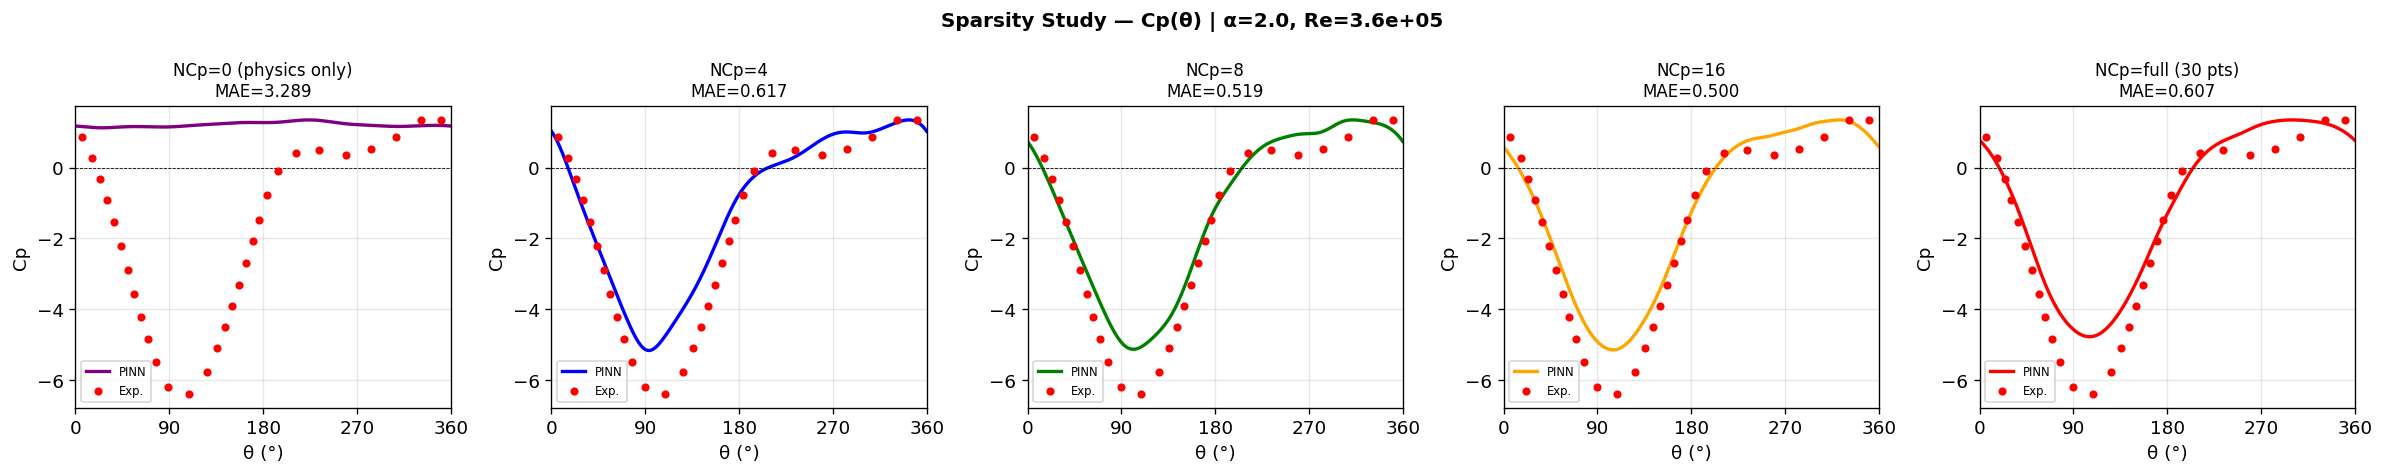

Fig 1 saved ✓


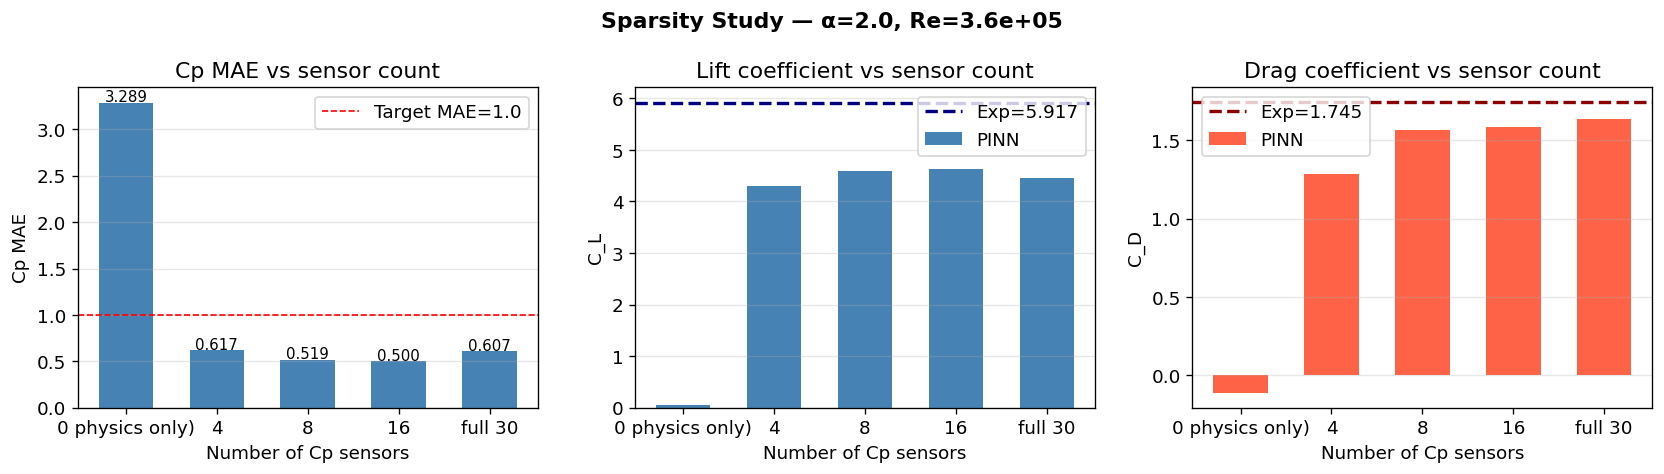

Fig 2 saved ✓


KeyError: 'epoch'

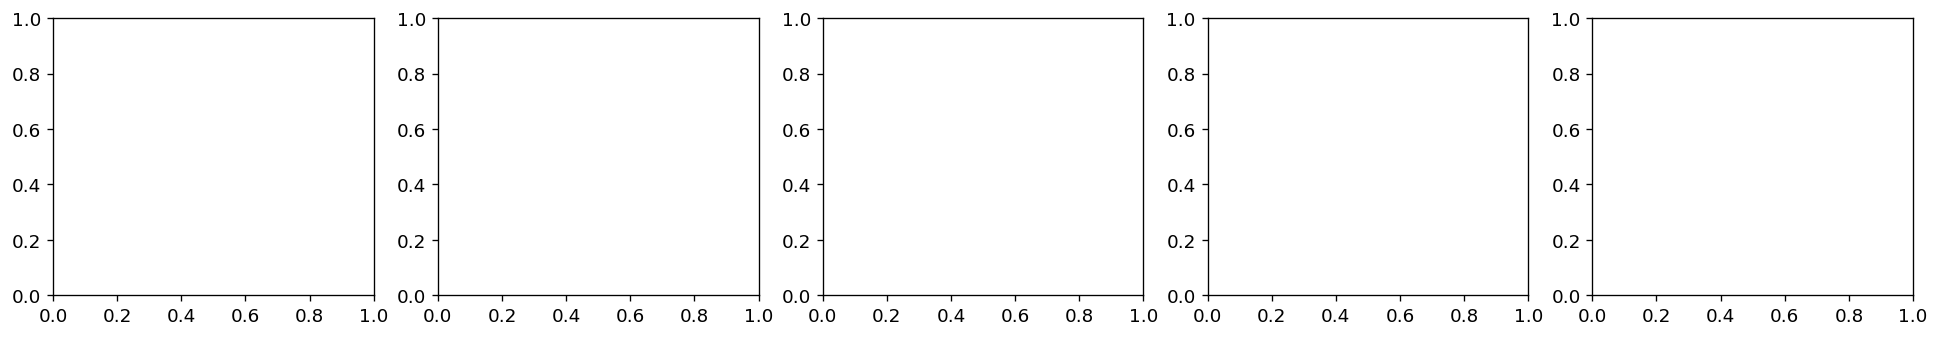

In [6]:
# ── CELL 5: Results ──────────────────────────────────────────────
# Reloads from Drive if session was restarted after Cell 4
import json as _json, os as _os, numpy as np

RESULTS_FILE = f"{OUT_DIR}/sparsity_results_alpha{ALPHA}.json"

if "sparsity_results" not in dir() or len(sparsity_results) == 0:
    if _os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE) as f:
            sparsity_results = _json.load(f)
        for k in sparsity_results:
            sparsity_results[k]["Cp_pred"] = np.array(sparsity_results[k]["Cp_pred"])
            sparsity_results[k]["th_deg"]  = np.array(sparsity_results[k]["th_deg"])
        print(f"Loaded {len(sparsity_results)} results from Drive")
    else:
        raise RuntimeError("No results found. Run Cell 4 first.")

print(f"Results available for NCp: {list(sparsity_results.keys())}")
print()

# ── CELL 5: Results — sparsity table and figures ────────────────

# ── Table ────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  SPARSITY STUDY RESULTS — alpha={ALPHA}, Re={RE:.1e}")
print(f"{'='*65}")
print(f"  {'NCp':<8} {'MAE':>7} {'CL':>7} {'CL err%':>9} {'CD':>7} {'CD err%':>9} {'Time':>7}")
print(f"  {'-'*63}")

for ncp_str, r in sparsity_results.items():
    cl_err = abs(r["CL"]-cl_ref)/cl_ref*100
    cd_err = abs(r["CD"]-cd_ref)/cd_ref*100
    print(f"  {r['label']:<12} {r['mae']:>6.3f}  {r['CL']:>6.3f}  {cl_err:>7.1f}%  "
          f"{r['CD']:>6.3f}  {cd_err:>7.1f}%  {r['elapsed']:>5.1f}m")

print(f"  {'-'*63}")
print(f"  Exp reference:          CL={cl_ref:.3f}             CD={cd_ref:.3f}")
print(f"{'='*65}")

# ── Figure 1: Cp comparison grid ─────────────────────────────────
n_runs = len(sparsity_results)
fig, axes = plt.subplots(1, n_runs, figsize=(4*n_runs, 4))
colors = ["purple","blue","green","orange","red"]

for ax, (ncp_str, r), col in zip(axes, sparsity_results.items(), colors):
    ax.plot(r["th_deg"], r["Cp_pred"], "-", color=col, lw=2, label="PINN")
    ax.scatter(theta_exp, cp_exp, color="red", s=15, zorder=5, label="Exp.")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_title(f"{r['label']}\nMAE={r['mae']:.3f}", fontsize=10)
    ax.set_xlabel("θ (°)"); ax.set_ylabel("Cp")
    ax.set_xlim([0,360]); ax.set_xticks([0,90,180,270,360])
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f"Sparsity Study — Cp(θ) | α={ALPHA}, Re={RE:.1e}",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_Cp_grid.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 1 saved ✓")

# ── Figure 2: MAE vs NCp (key manuscript figure) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ncp_labels = [r["label"].replace("NCp=","").replace(" pts)","").replace("(","")
              for r in sparsity_results.values()]
ncp_x      = list(range(len(sparsity_results)))
maes       = [r["mae"] for r in sparsity_results.values()]
cls        = [r["CL"]  for r in sparsity_results.values()]
cds        = [r["CD"]  for r in sparsity_results.values()]

axes[0].bar(ncp_x, maes, color="steelblue", width=0.6)
axes[0].axhline(1.0, color="red", lw=1, ls="--", label="Target MAE=1.0")
axes[0].set_xticks(ncp_x); axes[0].set_xticklabels(ncp_labels)
axes[0].set_xlabel("Number of Cp sensors"); axes[0].set_ylabel("Cp MAE")
axes[0].set_title("Cp MAE vs sensor count")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")
for i,v in enumerate(maes):
    axes[0].text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9)

axes[1].bar(ncp_x, cls, color="steelblue", width=0.6, label="PINN")
axes[1].axhline(cl_ref, color="navy", lw=2, ls="--", label=f"Exp={cl_ref:.3f}")
axes[1].set_xticks(ncp_x); axes[1].set_xticklabels(ncp_labels)
axes[1].set_xlabel("Number of Cp sensors"); axes[1].set_ylabel("C_L")
axes[1].set_title("Lift coefficient vs sensor count")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(ncp_x, cds, color="tomato", width=0.6, label="PINN")
axes[2].axhline(cd_ref, color="darkred", lw=2, ls="--", label=f"Exp={cd_ref:.3f}")
axes[2].set_xticks(ncp_x); axes[2].set_xticklabels(ncp_labels)
axes[2].set_xlabel("Number of Cp sensors"); axes[2].set_ylabel("C_D")
axes[2].set_title("Drag coefficient vs sensor count")
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Sparsity Study — α={ALPHA}, Re={RE:.1e}", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 2 saved ✓")

# ── Figure 3: Loss curves for all runs ───────────────────────────
fig, axes = plt.subplots(1, n_runs, figsize=(4*n_runs, 3))
for ax, (ncp_str, r), col in zip(axes, sparsity_results.items(), colors):
    ep = r["history"]["epoch"]
    ax.semilogy(ep, r["history"]["loss"],  "k-",  lw=1.5, label="Total")
    ax.semilogy(ep, r["history"]["pde"],   "b--", lw=1,   label="PDE")
    ax.semilogy(ep, r["history"]["wall"],  "r-.", lw=1,   label="Wall")
    ax.semilogy(ep, r["history"]["cp"],    "g:",  lw=1,   label="Cp")
    ax.set_title(r["label"], fontsize=9)
    ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
    if ax == axes[0]: ax.set_ylabel("Loss"); ax.legend(fontsize=7)

plt.suptitle("Training loss — all sparsity runs", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sparsity_loss.png", bbox_inches="tight", dpi=150)
plt.show()
print("Fig 3 saved ✓")
print(f"\nAll figures saved to {OUT_DIR}")
